# Understanding Skeleton Recall Loss on My CoW Data

This notebook explains, on your own 3T/7T CoW segmentation data, what the custom `SkeletonRecall` trainer in `segmentation_nnunet_workspace/topcow-2024-nnunet` is doing.

It focuses on four questions:

1. How is the skeleton target built from the ground-truth mask?
2. What do the Dice, Cross-Entropy, and Skeleton-Recall terms each reward?
3. Why can Skeleton Recall help thin vascular structures?
4. Which types of prediction errors are punished more strongly by Skeleton Recall?

This notebook is intentionally **didactic**. It reproduces the main loss terms in a simplified binary setting so that the behavior is easy to inspect.

## What This Notebook Reproduces

The trainer of interest is:

- `nnUNetTrainerSkeletonRecall`

Its total loss is:

- `CrossEntropy + Dice + SkeletonRecall`

The important implementation details are:

- the dataloader creates an extra target called `skel`
- `skel` is a skeletonized version of the vessel mask
- by default, that skeleton is dilated twice, creating a small tube around the centerline
- the Skeleton Recall term measures whether the predicted foreground probability covers that centerline target

This notebook reproduces those ingredients and visualizes them on a real case.

In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy import ndimage as ndi
from skimage.morphology import dilation, skeletonize

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MANIFEST_CSV = REPO_ROOT / 'data/segmentation_nnunet/manifest_master_3t_gt7t.csv'
CASE_ID = '001_20240313'
SEED = 21
np.random.seed(SEED)
torch.manual_seed(SEED)

print('REPO_ROOT =', REPO_ROOT)
print('MANIFEST_CSV =', MANIFEST_CSV)
print('CASE_ID =', CASE_ID) 

REPO_ROOT = /home/ceib/jaalzate/NeuroFlow
MANIFEST_CSV = /home/ceib/jaalzate/NeuroFlow/data/segmentation_nnunet/manifest_master_3t_gt7t.csv
CASE_ID = 001_20240313


In [2]:
# Helper functions mirroring the relevant behavior from the segmentation and trainer code.

def load_nifti(path: Path):
    img = nib.load(str(path))
    arr = np.asarray(img.dataobj)
    return img, arr


def project_volume(vol: np.ndarray, method: str = 'max', percentile: float = 100.0) -> np.ndarray:
    if vol.ndim == 3:
        return vol.astype(np.float32)
    if vol.ndim != 4:
        raise ValueError(f'Expected 3D or 4D volume, got {vol.shape}')
    if method == 'max':
        return np.max(vol, axis=3).astype(np.float32)
    if method == 'median':
        return np.median(vol, axis=3).astype(np.float32)
    if method == 'percentile':
        return np.percentile(vol, percentile, axis=3).astype(np.float32)
    raise ValueError(method)


def robust_norm(vol: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    finite = vol[np.isfinite(vol)].astype(np.float32)
    lo, hi = np.percentile(finite, [1.0, 99.0])
    clipped = np.clip(vol, lo, hi)
    return ((clipped - lo) / (hi - lo + eps)).astype(np.float32)


def select_mask_3d(mask_data: np.ndarray, time_index: int = 0) -> np.ndarray:
    if mask_data.ndim == 3:
        return mask_data.astype(np.uint8)
    if mask_data.ndim == 4:
        return mask_data[..., time_index].astype(np.uint8)
    raise ValueError(mask_data.shape)


def build_tubed_skeleton(mask_3d: np.ndarray, do_tube: bool = True) -> np.ndarray:
    mask_bin = (mask_3d > 0)
    skel = skeletonize(mask_bin).astype(np.uint8)
    if do_tube:
        skel = dilation(dilation(skel)).astype(np.uint8)
    skel = (skel * mask_bin).astype(np.uint8)
    return skel


def probability_to_two_class_logits(p_fg: np.ndarray, eps: float = 1e-6) -> torch.Tensor:
    p_fg = np.clip(p_fg.astype(np.float32), eps, 1 - eps)
    fg_logit = np.log(p_fg / (1 - p_fg)).astype(np.float32)
    bg_logit = np.zeros_like(fg_logit, dtype=np.float32)
    logits = np.stack([bg_logit, fg_logit], axis=0)[None]
    return torch.from_numpy(logits)


def target_to_tensor(mask_3d: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(mask_3d.astype(np.int64))[None, None]


def memory_efficient_soft_dice_loss_binary(logits: torch.Tensor, target: torch.Tensor, smooth: float = 1e-5) -> float:
    probs = torch.softmax(logits, dim=1)[:, 1:]
    target_fg = (target > 0).float()
    axes = tuple(range(2, probs.ndim))
    intersect = (probs * target_fg).sum(axes)
    sum_pred = probs.sum(axes)
    sum_gt = target_fg.sum(axes)
    dc = (2 * intersect + smooth) / torch.clamp(sum_gt + sum_pred + smooth, min=1e-8)
    return float((-dc.mean()).detach().cpu())


def cross_entropy_loss_binary(logits: torch.Tensor, target: torch.Tensor) -> float:
    ce = F.cross_entropy(logits, target[:, 0].long())
    return float(ce.detach().cpu())


def soft_skeleton_recall_loss_binary(logits: torch.Tensor, skeleton_target: torch.Tensor, smooth: float = 1e-5) -> float:
    probs = torch.softmax(logits, dim=1)[:, 1:]
    skel_fg = (skeleton_target > 0).float()
    axes = tuple(range(2, probs.ndim))
    inter = (probs * skel_fg).sum(axes)
    sum_skel = skel_fg.sum(axes)
    recall = (inter + smooth) / torch.clamp(sum_skel + smooth, min=1e-8)
    return float((-recall.mean()).detach().cpu())


def total_skeleton_recall_objective(logits: torch.Tensor, target: torch.Tensor, skel: torch.Tensor):
    ce = cross_entropy_loss_binary(logits, target)
    dice = memory_efficient_soft_dice_loss_binary(logits, target)
    srec = soft_skeleton_recall_loss_binary(logits, skel)
    total = ce + dice + srec
    return {
        'ce_loss': ce,
        'dice_loss': dice,
        'skeleton_recall_loss': srec,
        'total_loss': total,
    }


def middle_slice(mask_3d: np.ndarray) -> int:
    z_profile = mask_3d.sum(axis=(0, 1))
    nz = np.flatnonzero(z_profile > 0)
    if len(nz) == 0:
        return mask_3d.shape[2] // 2
    return int(nz[len(nz) // 2])


def show_overlay(base, mask=None, skel=None, title=''):
    plt.figure(figsize=(6, 6))
    plt.imshow(base.T, origin='lower', cmap='gray')
    if mask is not None:
        plt.contour(mask.T, levels=[0.5], colors='cyan', linewidths=1.0)
    if skel is not None:
        plt.contour(skel.T, levels=[0.5], colors='red', linewidths=1.0)
    plt.title(title)
    plt.axis('off')
    plt.show()

## Load One Real Case

We now load:

- the 3T magnitude image from the manifest
- the aligned CoW ground-truth mask
- the `max-projection + robust normalization` image that is closest to the segmentation pipeline you are currently using

This gives us a concrete volume where we can inspect the vessel mask and the centerline target.

In [7]:
manifest = pd.read_csv(MANIFEST_CSV)
row = manifest.loc[manifest['case_id'] == CASE_ID].iloc[0]

mag_path = REPO_ROOT / 'data' / row['lr_mag'][3:]
mask_path = REPO_ROOT / 'data' / row['mask_gt'][3:]

mag_img, mag_data = load_nifti(mag_path)
mask_img, mask_data = load_nifti(mask_path)

mask_3d = (select_mask_3d(mask_data) > 0).astype(np.uint8)
mag_proj = project_volume(mag_data, method='max')
mag_proj_robust = robust_norm(mag_proj)
skel_tube = build_tubed_skeleton(mask_3d, do_tube=True)
skel_thin = build_tubed_skeleton(mask_3d, do_tube=False)

z = middle_slice(mask_3d)

print('mag_data shape      =', mag_data.shape)
print('mask_3d shape       =', mask_3d.shape)
print('mag_proj shape      =', mag_proj.shape)
print('skeleton voxels     =', int(skel_thin.sum()))
print('tubed skeleton voxels =', int(skel_tube.sum()))
print('slice z             =', z)

mag_data shape      = (147, 99, 48, 9)
mask_3d shape       = (147, 99, 48)
mag_proj shape      = (147, 99, 48)
skeleton voxels     = 993
tubed skeleton voxels = 8923
slice z             = 24


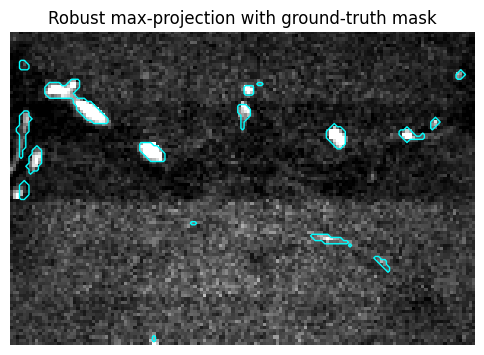

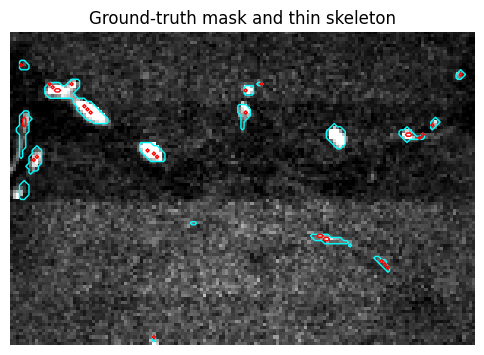

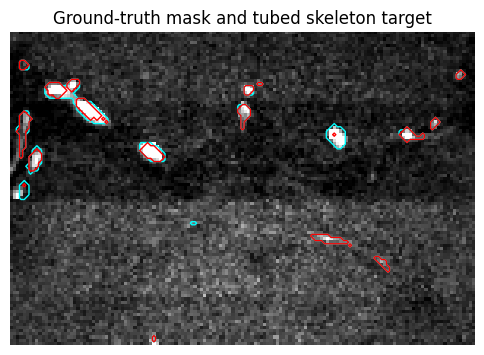

In [8]:
show_overlay(mag_proj_robust[:, :, z], mask_3d[:, :, z], None, title='Robust max-projection with ground-truth mask')
show_overlay(mag_proj_robust[:, :, z], mask_3d[:, :, z], skel_thin[:, :, z], title='Ground-truth mask and thin skeleton')
show_overlay(mag_proj_robust[:, :, z], mask_3d[:, :, z], skel_tube[:, :, z], title='Ground-truth mask and tubed skeleton target')

## Why The Tubed Skeleton Matters

The skeleton term is not computed on the full vessel mask. It is computed on a centerline target.

In this trainer, the centerline is dilated twice. That produces a small tube around the skeleton. This matters because:

- a 1-voxel-thin skeleton is very brittle
- a small tube makes supervision more tolerant to tiny centerline offsets
- the loss still focuses on vessel continuity, not only on full-volume overlap

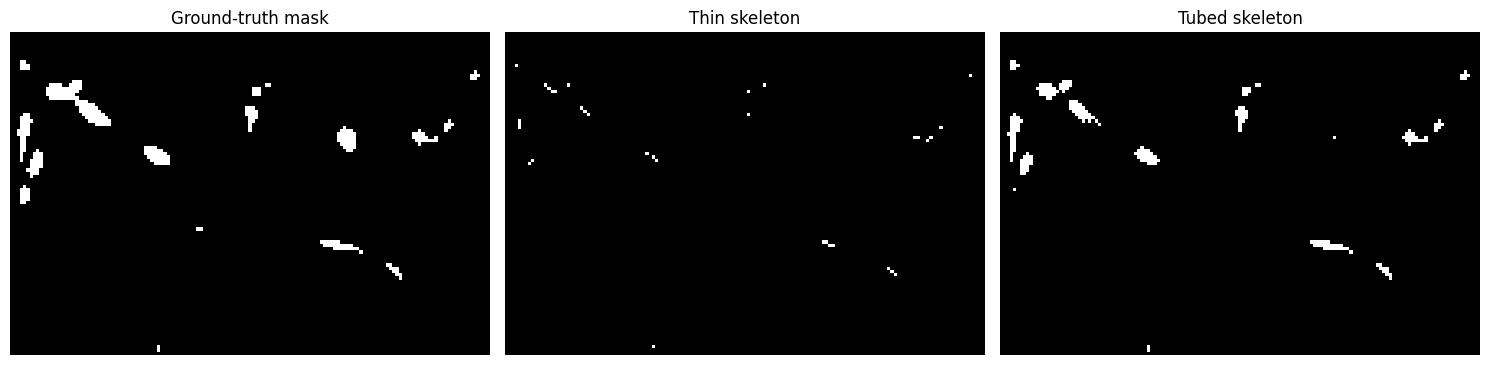

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask_3d[:, :, z].T, origin='lower')
axes[0].set_title('Ground-truth mask')
axes[1].imshow(skel_thin[:, :, z].T, origin='lower')
axes[1].set_title('Thin skeleton')
axes[2].imshow(skel_tube[:, :, z].T, origin='lower')
axes[2].set_title('Tubed skeleton')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Build Several Prediction Patterns

To understand the loss behavior, it is useful to compare different kinds of prediction errors on the same anatomy.

We create four simple foreground-probability maps:

- `perfect`: matches the mask closely
- `thick`: over-segments and makes vessels thicker
- `broken`: removes part of a vessel, creating a continuity error
- `shifted`: keeps shape but moves it slightly

These are not model outputs. They are controlled examples that make the behavior of the loss terms easier to interpret.

In [10]:
mask_bool = mask_3d.astype(bool)

perfect = np.where(mask_bool, 0.97, 0.03).astype(np.float32)

thick_mask = ndi.binary_dilation(mask_bool, iterations=2)
thick = np.where(thick_mask, 0.95, 0.05).astype(np.float32)

broken_mask = mask_bool.copy()
ys, xs, zs = np.where(mask_bool)
if len(zs) > 0:
    z_break = int(np.median(zs))
    x_min, x_max = np.percentile(xs, [35, 65]).astype(int)
    y_min, y_max = np.percentile(ys, [35, 65]).astype(int)
    broken_mask[y_min:y_max, x_min:x_max, max(0, z_break-1):min(mask_bool.shape[2], z_break+2)] = False
broken = np.where(broken_mask, 0.97, 0.03).astype(np.float32)

shifted_mask = ndi.shift(mask_bool.astype(np.float32), shift=(2, -2, 0), order=0) > 0.5
shifted = np.where(shifted_mask, 0.95, 0.05).astype(np.float32)

candidates = {
    'perfect': perfect,
    'thick': thick,
    'broken': broken,
    'shifted': shifted,
}

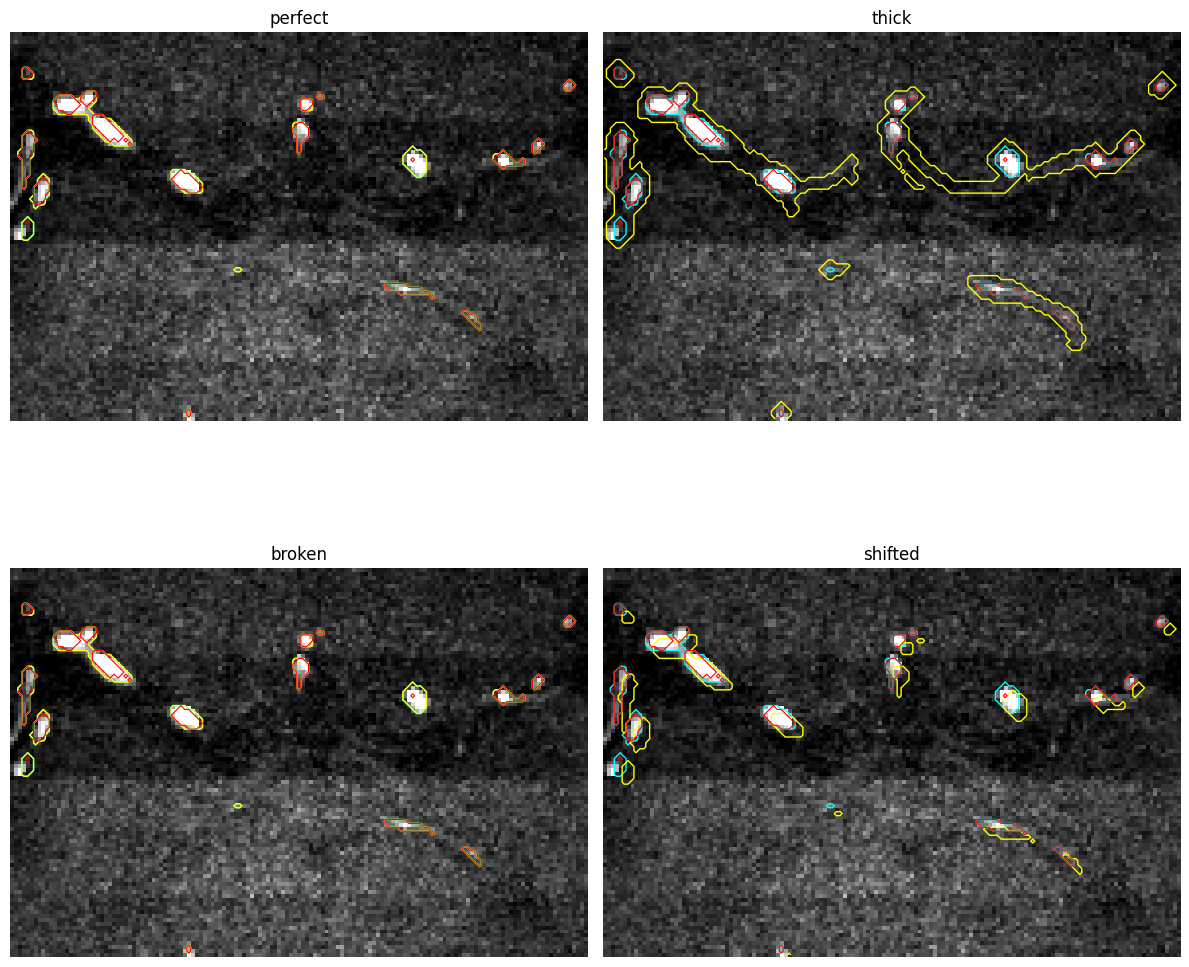

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (name, pred) in zip(axes.ravel(), candidates.items()):
    ax.imshow(mag_proj_robust[:, :, z].T, origin='lower', cmap='gray')
    ax.contour(mask_3d[:, :, z].T, levels=[0.5], colors='cyan', linewidths=1.0)
    ax.contour((pred[:, :, z] > 0.5).T, levels=[0.5], colors='yellow', linewidths=1.0)
    ax.contour(skel_tube[:, :, z].T, levels=[0.5], colors='red', linewidths=0.8)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Compute The Three Loss Terms

We now compute the simplified binary equivalents of the three training terms:

- Cross-Entropy on the full mask
- Dice loss on the full mask
- Skeleton Recall loss on the tubed skeleton target

Interpretation:

- lower is better for all three values
- more negative Dice or Skeleton Recall means higher overlap/recall, because the implementation returns the negative score
- the total loss is the sum of the three terms with unit weights

In [12]:
target_t = target_to_tensor(mask_3d)
skel_t = target_to_tensor(skel_tube)

rows = []
for name, pred in candidates.items():
    logits = probability_to_two_class_logits(pred)
    metrics = total_skeleton_recall_objective(logits, target_t, skel_t)
    rows.append({'prediction': name, **metrics})

results = pd.DataFrame(rows).set_index('prediction').sort_values('total_loss')
results

,ce_loss,dice_loss,skeleton_recall_loss,total_loss
prediction,,,,
perfect,0.030459,-0.590503,-0.970000,-1.530044
broken,0.030484,-0.590373,-0.969789,-1.529678
thick,0.173827,-0.326358,-0.950000,-1.102532
shifted,0.122044,-0.223754,-0.418150,-0.519860


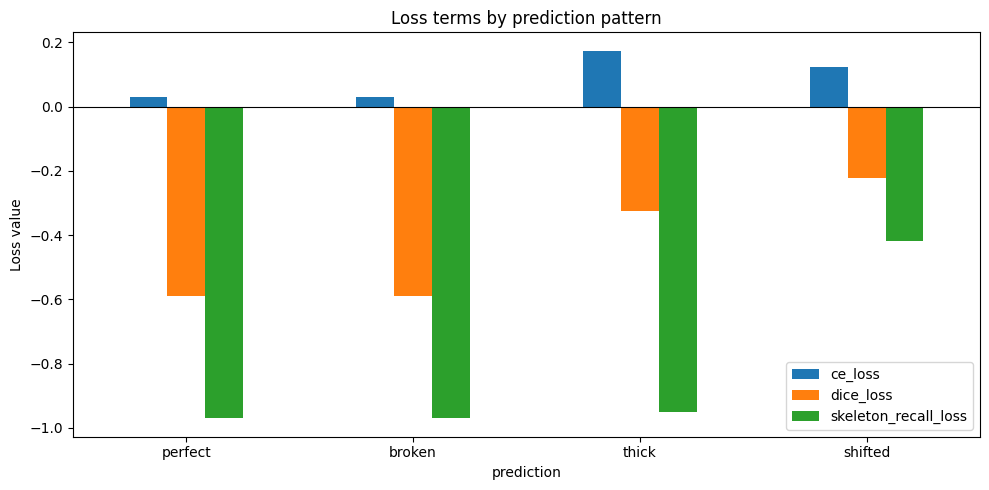

In [13]:
ax = results[['ce_loss', 'dice_loss', 'skeleton_recall_loss']].plot.bar(figsize=(10, 5))
ax.set_title('Loss terms by prediction pattern')
ax.set_ylabel('Loss value')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## How To Read These Results

Typical pattern you should expect:

- `thick` predictions often keep a decent Dice score because they still cover most vessels
- `broken` predictions may look acceptable in volume overlap but suffer more on Skeleton Recall because they miss centerline support
- `shifted` predictions often hurt all terms, but especially the skeleton-centered term if the centerline tube is no longer covered well

That is the main role of Skeleton Recall in vascular segmentation:

- it pushes the network to preserve vessel continuity
- it makes missed centerlines more expensive
- it reduces the tendency to optimize only for bulk overlap

## Optional: Compare Thin Skeleton vs Tubed Skeleton

The trainer uses a tubed skeleton, not only a one-voxel-thin centerline. This cell shows how much that changes the Skeleton Recall term.

In [14]:
skel_thin_t = target_to_tensor(skel_thin)
rows = []
for name, pred in candidates.items():
    logits = probability_to_two_class_logits(pred)
    thin_loss = soft_skeleton_recall_loss_binary(logits, skel_thin_t)
    tube_loss = soft_skeleton_recall_loss_binary(logits, skel_t)
    rows.append({
        'prediction': name,
        'thin_skeleton_recall_loss': thin_loss,
        'tubed_skeleton_recall_loss': tube_loss,
    })

pd.DataFrame(rows).set_index('prediction')

,thin_skeleton_recall_loss,tubed_skeleton_recall_loss
prediction,,
perfect,-0.970000,-0.970000
thick,-0.950000,-0.950000
broken,-0.970000,-0.969789
shifted,-0.347281,-0.418150


## Optional: Run On Another Case

Change `CASE_ID` near the top of the notebook and rerun the notebook.

Good follow-up cases are:

- a simple case with large, clean vessels
- a difficult case with thin branches or weak contrast
- a case where your model visually breaks continuity in one branch

## Notes And Limitations

This notebook is intentionally simplified.

It does **not** reproduce every training detail, such as:

- deep supervision across multiple output scales
- distributed batch aggregation
- the exact stochastic optimization trajectory of a trained network
- the full multiclass generalization used in some TopCoW settings

What it **does** reproduce faithfully is the key logic behind the custom trainer:

- skeleton target generation
- tubed centerline supervision
- CE + Dice + Skeleton Recall composition

That is enough to understand why the loss prefers continuity-preserving predictions on thin vessels.